In [10]:
import os, re, sys, subprocess, urllib.request

REQ_FILE = "requirements.txt"
REQ_URL = "https://raw.githubusercontent.com/Conner-Blignaut/Stock-Bot/main/requirements.txt"  # change 'main' if your branch differs

# 1. Get requirements.txt if it isn't next to the notebook
if not os.path.exists(REQ_FILE):
    urllib.request.urlretrieve(REQ_URL, REQ_FILE)

# 2. Clean it: accept "name==1.2.3" lines, and convert "name   1.2.3" (pip list format) to "name==1.2.3"
clean = []
with open(REQ_FILE) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#") or line.startswith("-"):
            continue
        parts = line.split()
        if len(parts) == 2 and re.match(r"^\d", parts[1]):      # pip list style
            clean.append(f"{parts[0]}=={parts[1]}")
        elif len(parts) == 1:                                    # already valid (name or name==version)
            clean.append(parts[0])

with open("requirements_clean.txt", "w") as f:
    f.write("\n".join(clean) + "\n")

# 3. Install into the same Python environment the notebook is using
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements_clean.txt"])
print(f"Installed {len(clean)} packages from {REQ_FILE}.")

Installed 6 packages from requirements.txt.


Timing self-check passed.
Loading cached data from c:\Users\Conner\Desktop\github_repository\StockAnalysisBot\VST_2019-01-01_2026-09-30.csv

=== VST: 1556 train days, 389 test days (2025-03-13 to 2026-09-29) ===
Selected ARIMA(2, 0, 0) (AIC=-6675.02, 0 failed fits)

Forecast quality (test):
  ARIMA RMSE           0.03262
  Hit rate             0.51157

Test-period results (cost = 5 bps):
                 Sharpe   Sharpe 95% CI Total return  Max DD Ann. turnover Trades
Buy & hold         0.12  [-1.52,  1.74]        16.7%  -38.0%           0.0      0
ARIMA long/short   0.82  [-0.78,  2.43]       104.4%  -37.3%         222.2    172

VST: ARIMA(2, 0, 0) fit on 1945 days, last date 2026-09-29
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1945
Model:                 ARIMA(2, 0, 0)   Log Likelihood                4114.671
Date:                Thu, 01 Oct 2026   AIC                       

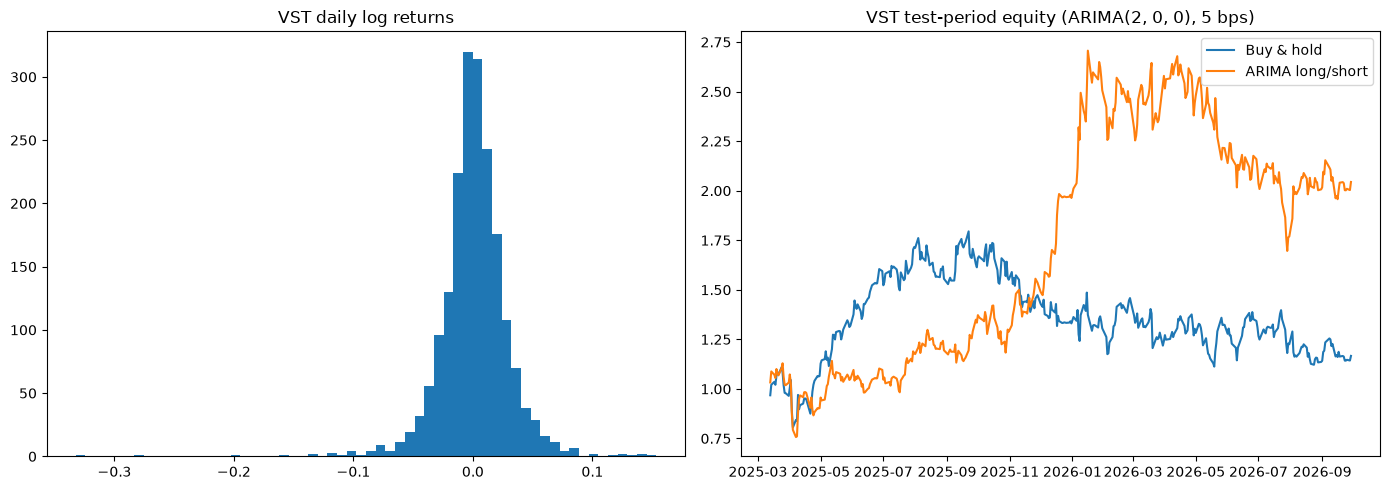

In [4]:
from __future__ import annotations
import itertools
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA


SYMBOLS = ["VST"]
START, END = "2019-01-01", "2026-09-30"
TRAIN_RATIO = 0.80
MAX_P, MAX_Q = 3, 3
REFIT_EVERY = 20   
MOMENTUM_WINDOW = 20
COST_BPS = 5                
COST_SWEEP = (0, 5, 10, 20, 100)
RISK_FREE = 0.04        
PERIODS = 252
N_BOOT = 2000

try:
    DATA_DIR = Path(__file__).resolve().parent
except NameError:\
    DATA_DIR = Path.cwd()


def load_prices(symbol: str, start: str, end: str) -> pd.DataFrame:

    path = DATA_DIR / f"{symbol}_{start}_{end}.csv"
    if path.exists():
        print(f"Loading cached data from {path}")
        df = pd.read_csv(path, index_col=0)
    else:
        df = yf.Ticker(symbol).history(start=start, end=end)
        if df.empty:
            raise ValueError(f"No data returned for {symbol}")
        df.to_csv(path)
        print(f"Saved data to {path}")

    idx = pd.to_datetime(df.index, utc=True).tz_convert("America/New_York")
    df.index = idx.tz_localize(None).normalize()
    df.index.name = "Date"
    return df


def select_order(series: np.ndarray, d: int = 0, max_p: int = MAX_P, max_q: int = MAX_Q):

    best_aic, best_order, failures = np.inf, (0, d, 0), 0
    for p, q in itertools.product(range(max_p + 1), range(max_q + 1)):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                aic = ARIMA(series, order=(p, d, q)).fit().aic
        except Exception:
            failures += 1
            continue
        if aic < best_aic:
            best_aic, best_order = aic, (p, d, q)
    print(f"Selected ARIMA{best_order} (AIC={best_aic:.2f}, {failures} failed fits)")
    return best_order


def walk_forward_forecast(ret: pd.Series, start: int, order, refit_every: int = REFIT_EVERY) -> pd.Series:

    values = ret.to_numpy()
    out = pd.Series(np.nan, index=ret.index)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = ARIMA(values[:start], order=order).fit()
        steps = 0
        for i in range(start - 1, len(values) - 1):
            out.iloc[i] = float(np.asarray(res.forecast(1))[0])
            steps += 1
            if steps % refit_every == 0:
                res = ARIMA(values[: i + 2], order=order).fit()
            else:
                res = res.append(values[i + 1 : i + 2], refit=False)
    return out


def backtest(signal: pd.Series, ret: pd.Series, cost_bps: float = COST_BPS):
    pos = signal.reindex(ret.index).fillna(0.0)
    held = pos.shift(1).fillna(0.0)
    turnover = held.diff().abs().fillna(held.abs())
    net = held * ret - turnover * cost_bps / 1e4
    return net, held, turnover


def sharpe(net: pd.Series) -> float:
    excess = net - RISK_FREE / PERIODS
    sd = excess.std()
    return float(excess.mean() / sd * np.sqrt(PERIODS)) if sd > 0 else np.nan


def sharpe_ci(net: pd.Series, n_boot: int = N_BOOT, seed: int = 0):
    rng = np.random.default_rng(seed)
    x = net.to_numpy() - RISK_FREE / PERIODS
    samples = rng.choice(x, size=(n_boot, len(x)), replace=True)
    sd = samples.std(axis=1, ddof=1)
    s = np.where(sd > 0, samples.mean(axis=1) / np.where(sd > 0, sd, 1) * np.sqrt(PERIODS), np.nan)
    return tuple(np.nanpercentile(s, [2.5, 97.5]))


def performance(net: pd.Series, held: pd.Series, turnover: pd.Series) -> dict:
    equity = np.exp(net.cumsum())
    lo, hi = sharpe_ci(net)
    return {
        "Sharpe": sharpe(net),
        "Sharpe 95% CI": f"[{lo:5.2f}, {hi:5.2f}]",
        "Total return": equity.iloc[-1] - 1,
        "Max DD": (equity / equity.cummax() - 1).min(),
        "Ann. turnover": turnover.mean() * PERIODS,
        "Trades": int((turnover > 0).sum()),
    }


def forecast_metrics(pred: np.ndarray, actual: np.ndarray, train_mean: float) -> dict:
    rmse = lambda e: float(np.sqrt(np.mean(e**2)))
    return {
        "ARIMA RMSE": rmse(actual - pred),
        "Hit rate": float((np.sign(pred) == np.sign(actual)).mean()),
    }


def self_check():
    rng = np.random.default_rng(1)
    idx = pd.bdate_range("2020-01-01", periods=500)
    ret = pd.Series(rng.normal(0, 0.02, len(idx)), index=idx)

    oracle = np.sign(ret.shift(-1))
    net, _, _ = backtest(oracle, ret, cost_bps=0)
    assert np.isclose(net.sum(), ret.iloc[1:].abs().sum()), "oracle timing is off"

    net, _, _ = backtest(np.sign(ret), ret, cost_bps=0)
    assert net.sum() < 0.5 * ret.abs().sum(), "same-day look-ahead detected"
    print("Timing self-check passed.")


def run_symbol(symbol: str):
    prices = load_prices(symbol, START, END)
    close = prices["Close"].astype(float)
    ret = np.log(close).diff().dropna()

    n = int(len(ret) * TRAIN_RATIO)
    train, test = ret.iloc[:n], ret.iloc[n:]
    print(f"\n=== {symbol}: {len(train)} train days, {len(test)} test days "
          f"({test.index[0].date()} to {test.index[-1].date()}) ===")

    order = select_order(train.to_numpy(), d=0)
    fc = walk_forward_forecast(ret, n, order)

    pred = fc.iloc[n - 1 : -1].to_numpy()
    actual = test.to_numpy()
    fm = forecast_metrics(pred, actual, train.mean())
    print("\nForecast quality (test):")
    for k, v in fm.items():
        print(f"  {k:<20} {v:.5f}")

    signals = {
        "Buy & hold": pd.Series(1.0, index=ret.index),
        "ARIMA long/short": np.sign(fc),
    }

    rows, curves = {}, {}
    for name, sig in signals.items():
        net, held, turn = backtest(sig, ret, COST_BPS)
        net_t, held_t, turn_t = net.iloc[n:], held.iloc[n:], turn.iloc[n:]
        rows[name] = performance(net_t, held_t, turn_t)
        curves[name] = np.exp(net_t.cumsum())

    table = pd.DataFrame(rows).T
    fmt = {"Sharpe": "{:.2f}".format, "Total return": "{:.1%}".format,
           "Max DD": "{:.1%}".format, "Ann. turnover": "{:.1f}".format}
    print(f"\nTest-period results (cost = {COST_BPS} bps):")
    print(table.to_string(formatters={k: v for k, v in fmt.items() if k in table}))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(ret, bins=60)
    axes[0].set_title(f"{symbol} daily log returns")
    for name, eq in curves.items():
        axes[1].plot(eq.index, eq.values, label=name)
    axes[1].set_title(f"{symbol} test-period equity (ARIMA{order}, {COST_BPS} bps)")
    axes[1].legend()
    fig.tight_layout()
    return ret, order


def main():
    self_check()
    for symbol in SYMBOLS:
        ret, order = run_symbol(symbol)

        final = ARIMA(ret.to_numpy(), order=order).fit()
        print(f"\n{symbol}: ARIMA{order} fit on {len(ret)} days, last date {ret.index[-1].date()}")
        print(final.summary())
        next_ret = float(np.asarray(final.forecast(1))[0])
        print(f"Forecast next-day log return: {next_ret:+.4%}")
    plt.show()


if __name__ == "__main__":
    main()